In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [70]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [71]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4229,5451-YHYPW,Female,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),115.75,8443.7,No
6115,3831-YCPUO,Female,0,Yes,Yes,72,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),109.50,7854.9,No
5963,7163-OCEQI,Male,0,Yes,Yes,22,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,78.65,1663.75,No
597,5172-MIGPM,Male,0,No,No,4,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Mailed check,65.55,237.2,No


In [72]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
df_org.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [74]:
df=df_org.copy()

In [75]:
df=df.drop('customerID',axis=1)

In [76]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [77]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [78]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [79]:
df.shape

(7043, 20)

In [80]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

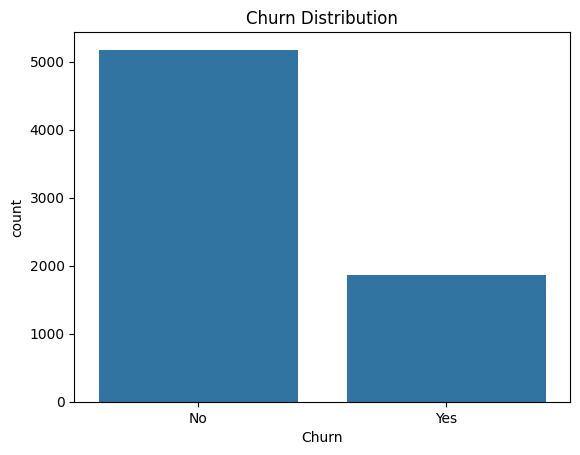

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

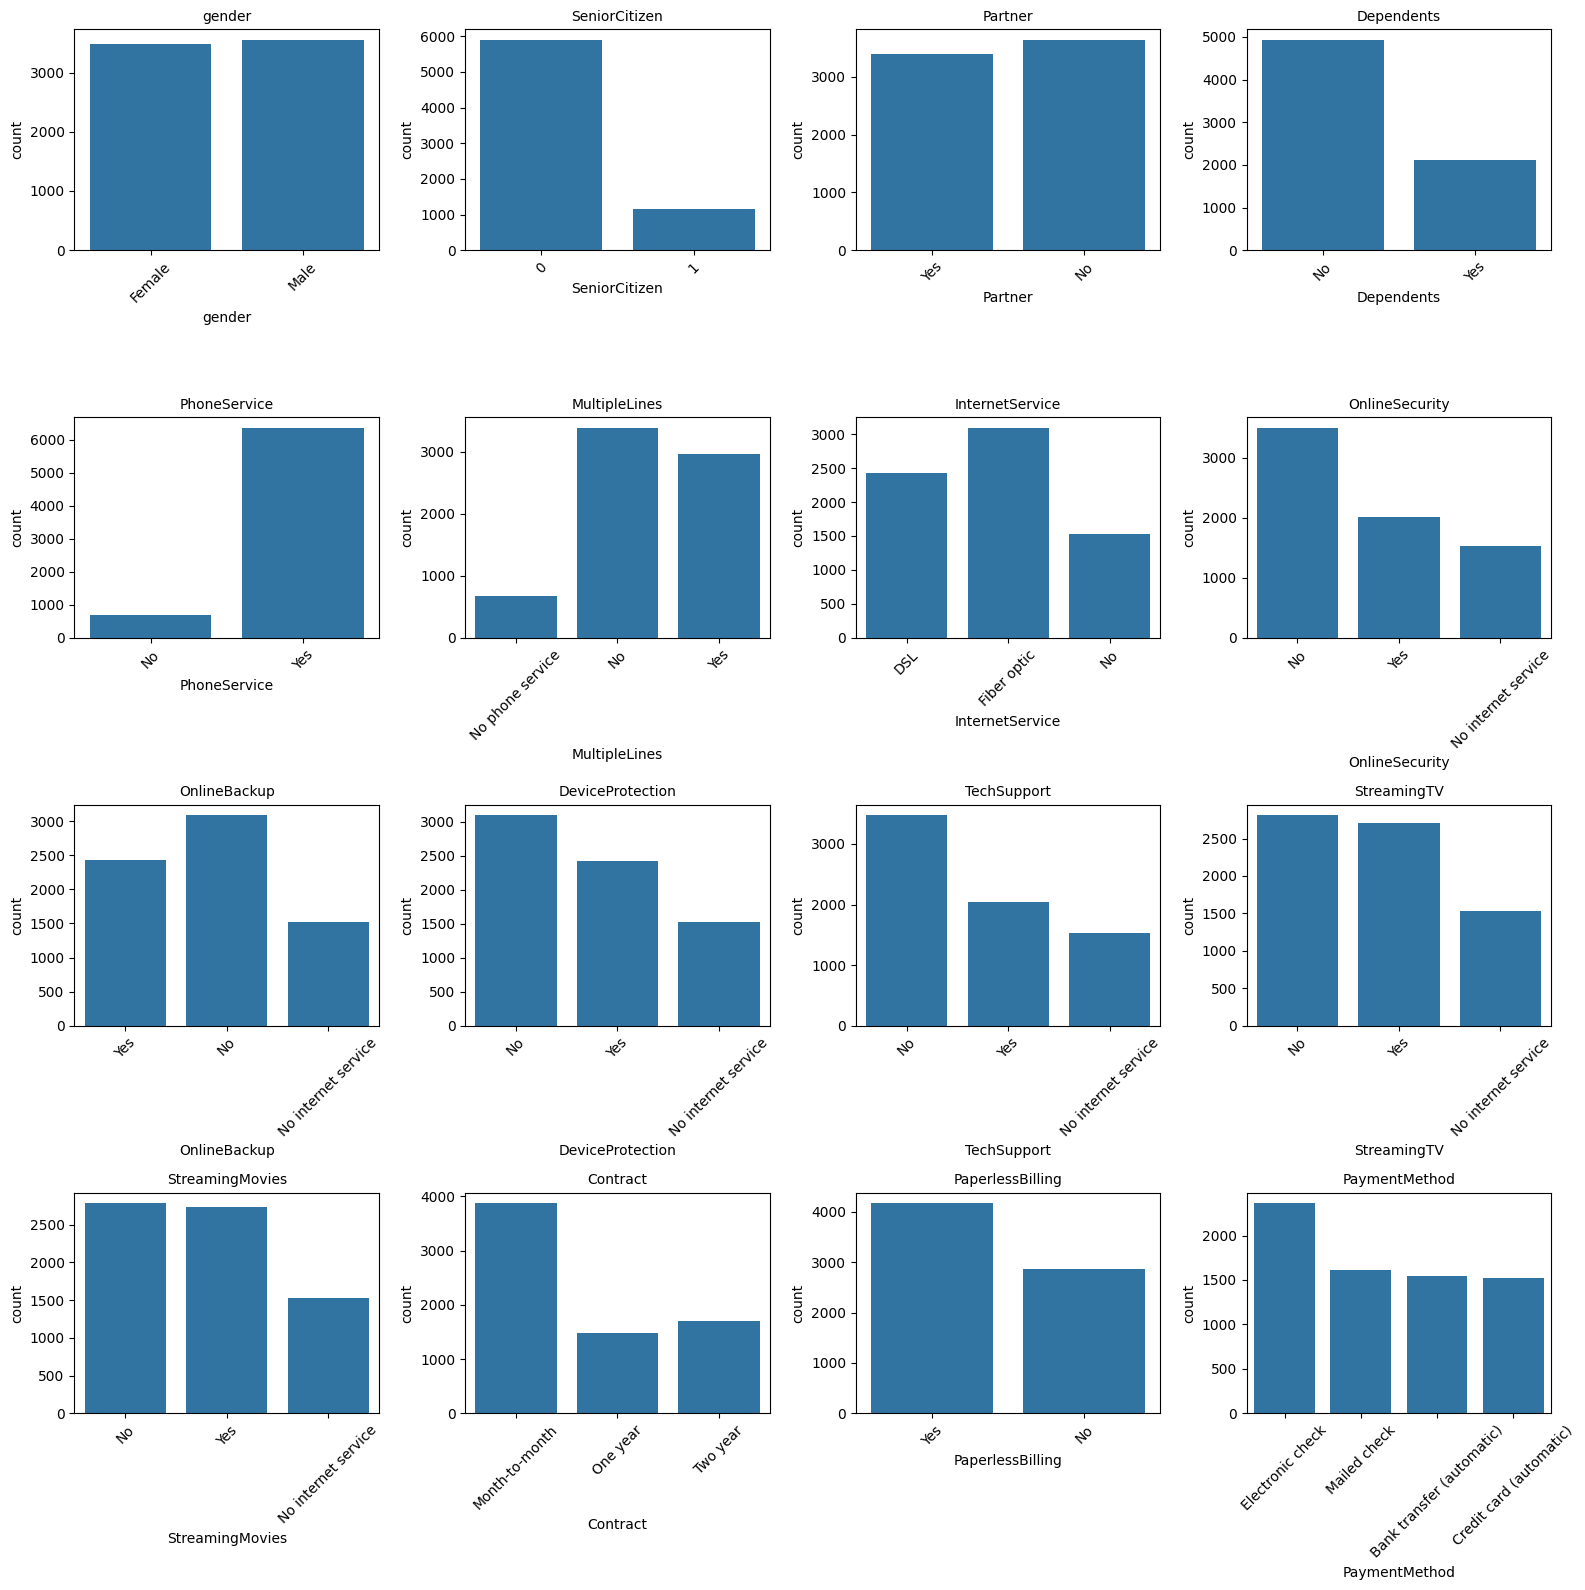

In [82]:
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod']

# create 4x4 figure
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# flatten converts 2D array of axes into 1D
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

# adjust spacing
plt.tight_layout()

plt.show()

In [83]:
#churn rate among seniors
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


<Axes: xlabel='InternetService', ylabel='count'>

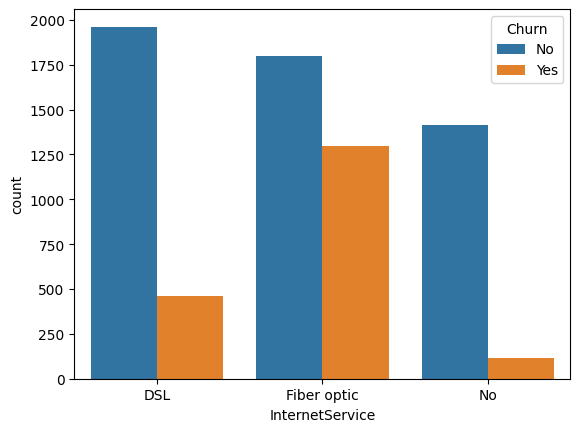

In [84]:
#fiber users often have higher churn in this datas
sns.countplot(x='InternetService', hue='Churn', data=df)
#users without support/security churn more

<Axes: xlabel='Contract', ylabel='count'>

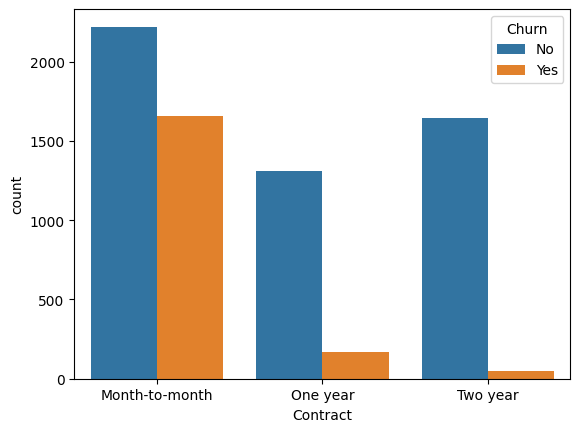

In [85]:
sns.countplot(x='Contract', hue='Churn', data=df)


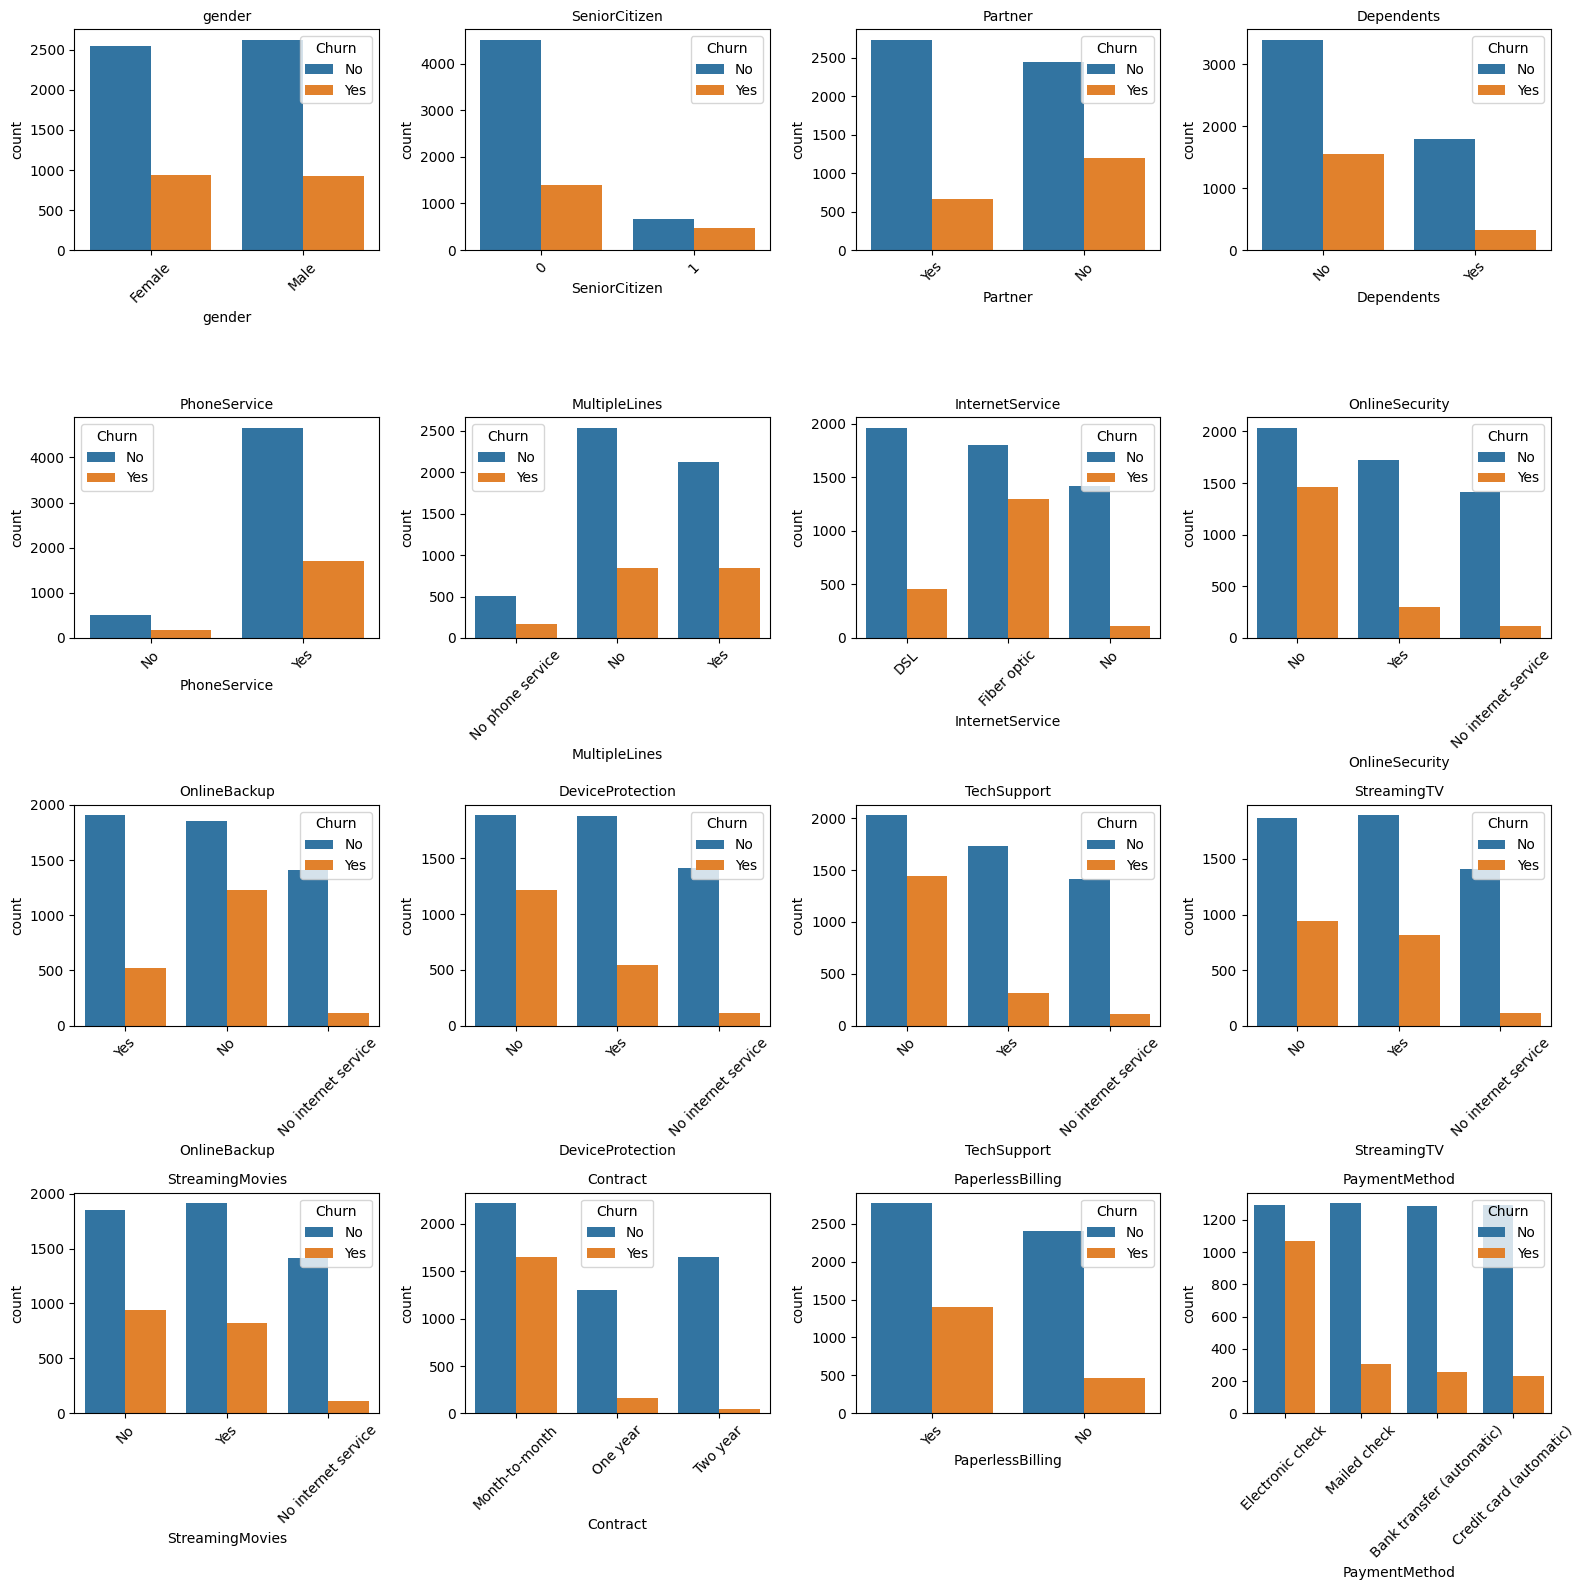

In [86]:
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod']

# create 4x4 figure
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# flatten converts 2D array of axes into 1D
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df[col],hue='Churn', ax=axes[i],data=df)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

# adjust spacing
plt.tight_layout()

plt.show()
#users without support/security churn more

In [87]:
#churners have lower tenure
#churners may have higher monthly charges

<Axes: xlabel='tenure', ylabel='Count'>

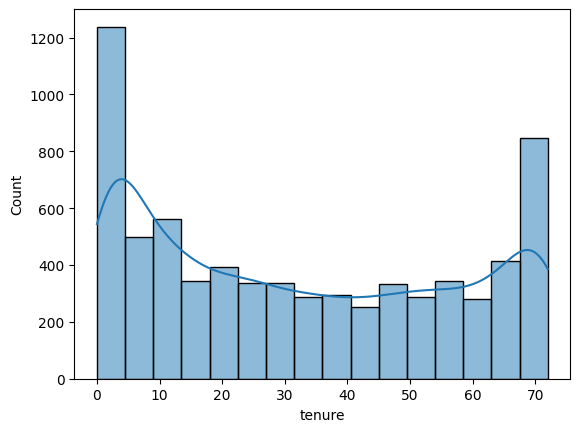

In [88]:
sns.histplot(df['tenure'], kde=True)

In [89]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

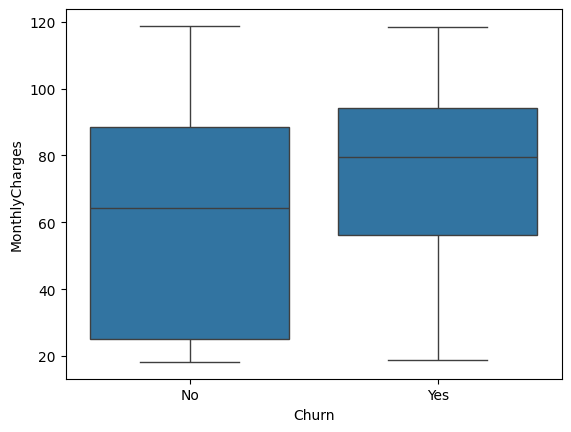

In [90]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

<Axes: xlabel='tenure', ylabel='Density'>

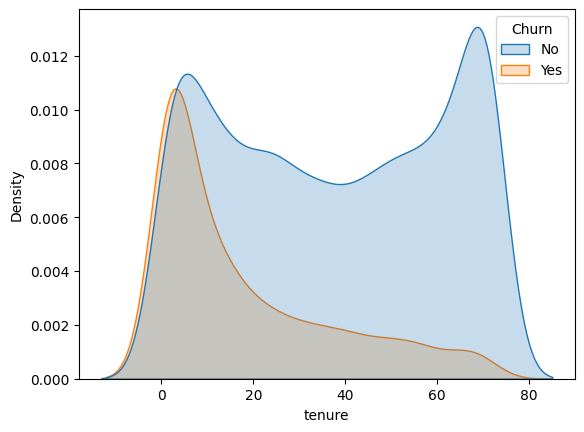

In [91]:

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)

<Axes: >

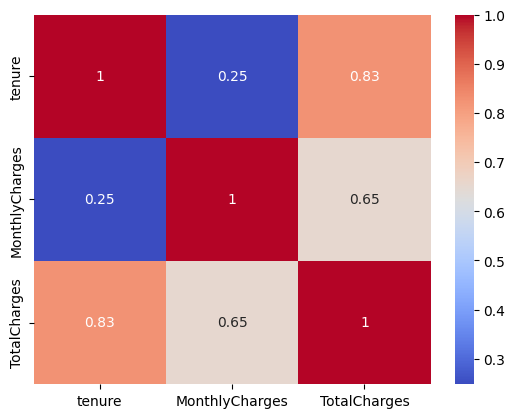

In [92]:
#Correlation Analysis
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='TotalCharges'>

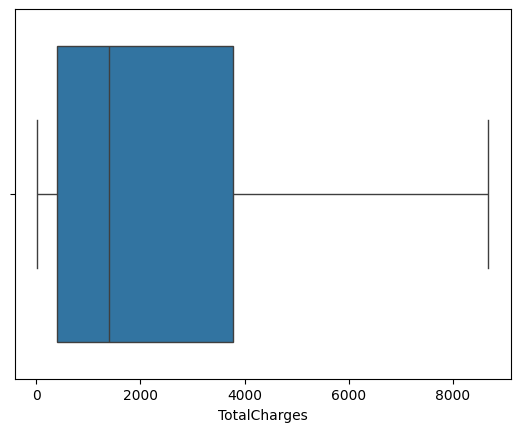

In [93]:
sns.boxplot(x=df['TotalCharges'])

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

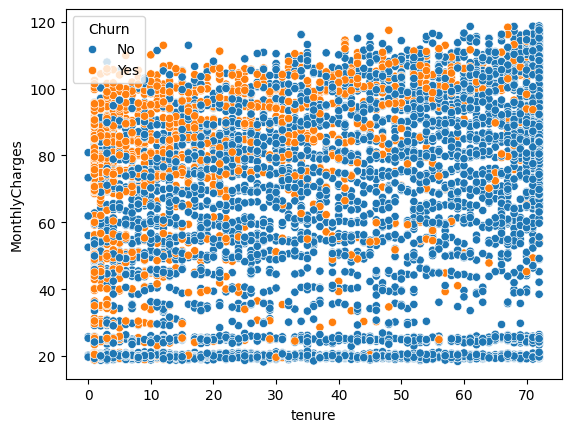

In [94]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)

In [96]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

multi_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [103]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [97]:
binary_map = {
    'Yes':1,
    'No':0
}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [102]:
preprocessor = ColumnTransformer([('num',StandardScaler(),num_cols ),
                                ('cat',OneHotEncoder(drop='first'),multi_cols)
                                    ],remainder='passthrough')

In [104]:
X_processed = preprocessor.fit_transform(X)

In [105]:
df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4891,Male,0,1,0,4,1,Yes,DSL,No,No,Yes,No,Yes,No,Month-to-month,0,Electronic check,65.60,250.10,0
6931,Male,0,0,0,58,1,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,One year,0,Bank transfer (automatic),99.15,5720.95,0
4160,Male,0,0,0,26,1,No,DSL,Yes,No,No,Yes,Yes,Yes,One year,0,Bank transfer (automatic),75.00,1908.35,0
3305,Male,1,0,0,38,1,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,0,Electronic check,94.75,3653.00,0
2900,Female,1,1,1,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,69.25,69.25,1
1772,Male,0,0,0,2,1,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,0,Electronic check,79.00,143.65,1
2791,Male,0,0,0,57,1,No,DSL,Yes,No,Yes,No,Yes,Yes,Two year,1,Bank transfer (automatic),74.35,4317.35,0
4442,Male,0,0,0,3,1,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,1,Electronic check,78.50,242.05,1
3219,Female,0,1,1,24,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,24.70,571.75,0
862,Male,1,1,0,20,1,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,73.65,1463.50,1


In [110]:
x_processed_df = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

x_processed_df.sample(10)

,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,...,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__PhoneService,remainder__PaperlessBilling
2434,-1.196004,-1.499330,-0.980644,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
2635,1.247218,-1.313208,-0.319021,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4966,-0.544478,-0.487295,-0.605475,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
5605,-0.910961,-0.151612,-0.758646,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
4468,-0.707359,-1.308223,-0.831005,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4674,-0.259435,-0.478986,-0.439765,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
55,-0.585198,1.019955,-0.233705,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
4174,0.188489,-1.201868,-0.577617,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3014,0.473531,0.812230,0.776246,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
3752,0.921455,-0.184848,0.394653,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [111]:
x_processed_df.describe()

,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,...,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__PhoneService,remainder__PaperlessBilling
count,7.043000e+03,7.043000e+03,7.043000e+03,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,-2.421273e-17,-6.406285e-17,-1.488074e-17,0.504756,0.096834,0.421837,0.439585,0.216669,0.216669,0.286668,...,0.209144,0.240664,0.216101,0.335794,0.228880,0.162147,0.483033,0.299588,0.903166,0.592219
std,1.000071e+00,1.000071e+00,1.000071e+00,0.500013,0.295752,0.493888,0.496372,0.412004,0.412004,0.452237,...,0.406726,0.427517,0.411613,0.472301,0.420141,0.368612,0.499748,0.458110,0.295752,0.491457
min,-1.318165e+00,-1.545860e+00,-9.991203e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-9.516817e-01,-9.725399e-01,-8.298459e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,-1.372744e-01,1.857327e-01,-3.904632e-01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,9.214551e-01,8.338335e-01,6.642871e-01,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.613701e+00,1.794352e+00,2.826743e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


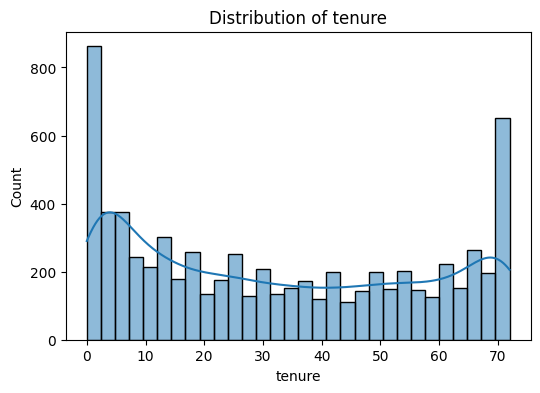

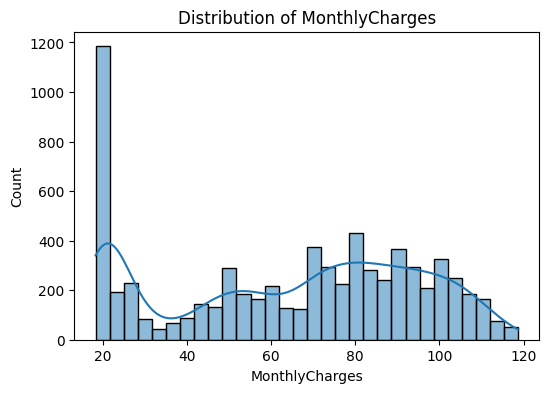

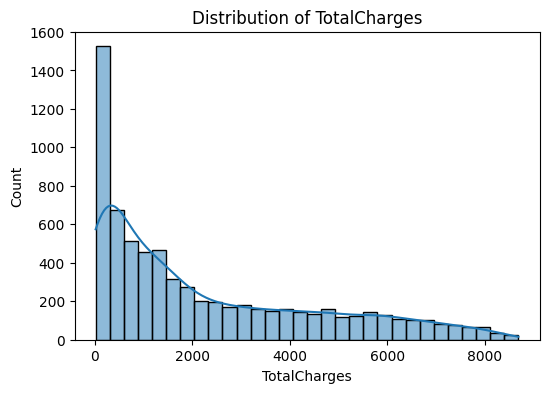

In [112]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )
    
    plt.title(f'Distribution of {col}')
    plt.show()

In [113]:
x_processed_df.shape

(7043, 30)

In [115]:
x_processed_df.to_csv(
    'processed_data.csv',
    index=False
)

<Axes: >

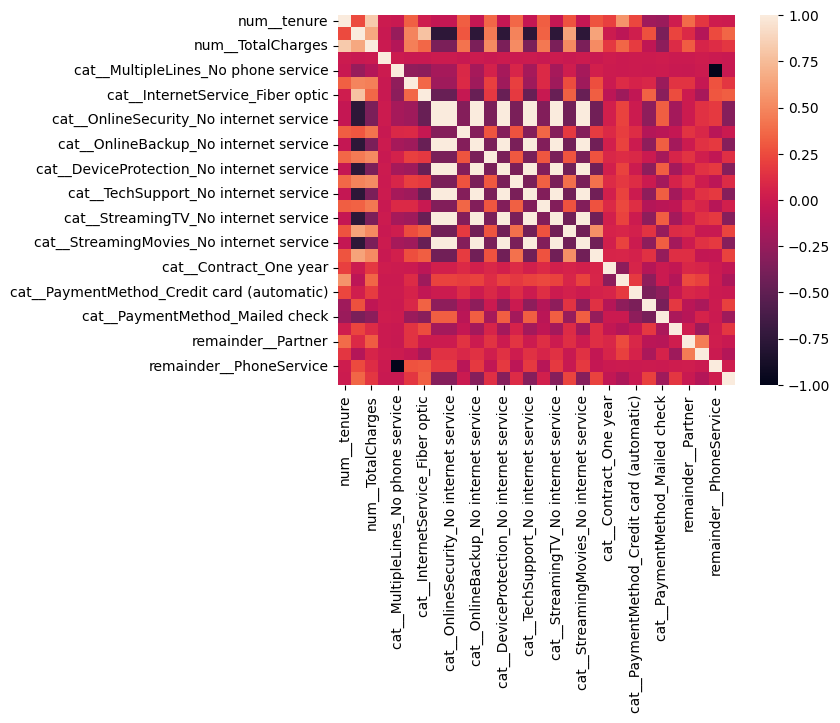

In [116]:
sns.heatmap(x_processed_df.corr())

In [119]:
corr_target = x_processed_df.corrwith(y)

corr_target = corr_target.sort_values(
    ascending=False
)

print(corr_target)

cat__InternetService_Fiber optic              0.308020
cat__PaymentMethod_Electronic check           0.301919
num__MonthlyCharges                           0.193356
remainder__PaperlessBilling                   0.191825
remainder__SeniorCitizen                      0.150889
cat__StreamingTV_Yes                          0.063228
cat__StreamingMovies_Yes                      0.061382
cat__MultipleLines_Yes                        0.040102
remainder__PhoneService                       0.011942
cat__gender_Male                             -0.008612
cat__MultipleLines_No phone service          -0.011942
cat__DeviceProtection_Yes                    -0.066160
cat__OnlineBackup_Yes                        -0.082255
cat__PaymentMethod_Mailed check              -0.091683
cat__PaymentMethod_Credit card (automatic)   -0.134302
remainder__Partner                           -0.150448
remainder__Dependents                        -0.164221
cat__TechSupport_Yes                         -0.164674
cat__Onlin

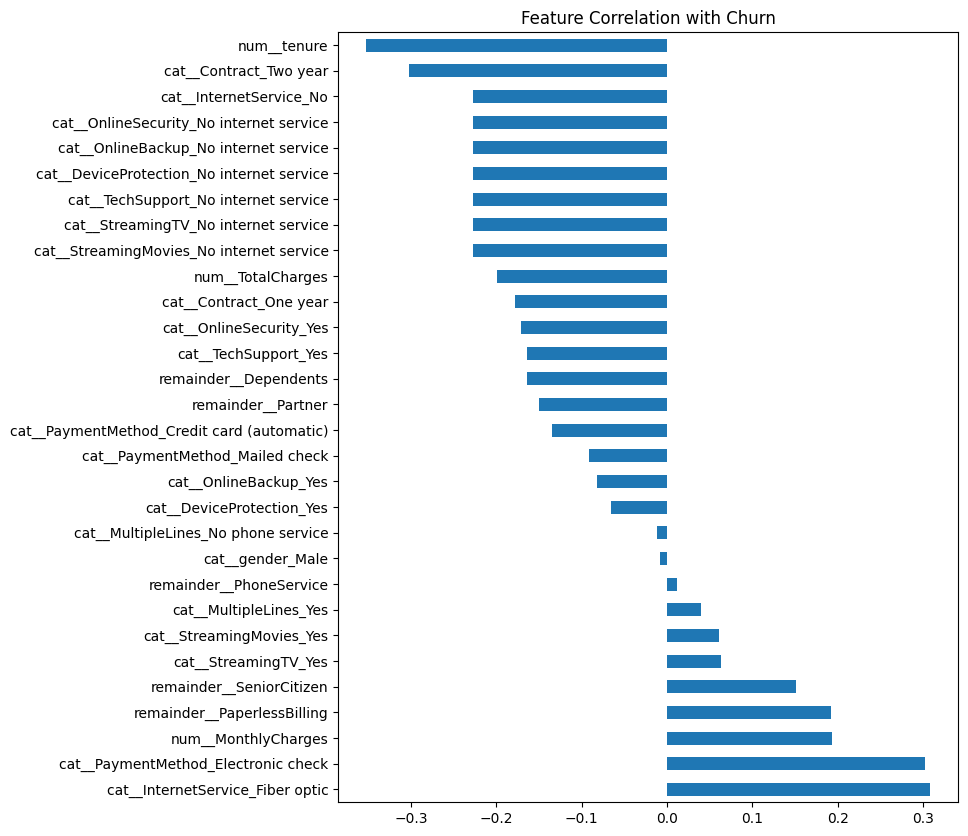

In [120]:
plt.figure(figsize=(8,10))

corr_target.plot(kind='barh')

plt.title('Feature Correlation with Churn')

plt.show()